In [1]:
import os
import tempfile

import scanpy as sc
from rich import print

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import

In [2]:
import pandas as pd
import numpy as np

### Load reference data

In [3]:
adata_atlas = sc.read('/home/bnvlab2/scVI_brain_organoids/organoids/scFates_atlas_subset_upd_timebins.h5ad')

In [6]:
adata_randall = sc.read('/home/bnvlab2/scVI_brain_organoids/organoids/neurons_scVI_scFates.h5ad')

In [7]:
genes_used2 = adata_atlas.var_names
common_genes2 = set(genes_used2) & set(adata_randall.var_names)
len(common_genes2)

23183

In [8]:
adata_atlas_sub = adata_atlas[:, list(common_genes2)].copy()

## Run DE

In [10]:
sc.tl.rank_genes_groups(
    adata_atlas, 
    groupby='t_bin_custom_upd', 
    method='wilcoxon',
    use_raw=False,
)

df_markers_atlas_all = sc.get.rank_genes_groups_df(adata_atlas, group=None)
df_markers_atlas_all.to_csv('/home/bnvlab2/scVI_brain_organoids/scFates/markers_atlas_t_bin_custom_upd_all_genes2.csv')

In [ ]:
df_markers_atlas_all = pd.read_csv('/home/bnvlab2/scVI_brain_organoids/scFates/markers_atlas_t_bin_custom_upd_all_genes2.csv', index_col=0)

In [11]:
sc.tl.rank_genes_groups(
    adata_atlas_sub, 
    groupby='t_bin_custom_upd', 
    method='wilcoxon',
    use_raw=False,
)

df_markers_atlas_common = sc.get.rank_genes_groups_df(adata_atlas_sub, group=None)
df_markers_atlas_common.to_csv('/home/bnvlab2/scVI_brain_organoids/scFates/markers_atlas_t_bin_custom_upd_common2.csv')

In [ ]:
df_markers_atlas_common = pd.read_csv('/home/bnvlab2/scVI_brain_organoids/scFates/markers_atlas_t_bin_custom_upd_common2.csv', index_col=0)

## Load query data

In [12]:

adata_full_WT = adata_randall[adata_randall.obs['True_Condition_PSEN'] == 'PSEN1WT']
adata_full_MUT = adata_randall[adata_randall.obs['True_Condition_PSEN'] != 'PSEN1WT']


In [13]:
adata_randall_sub = adata_randall[:, list(common_genes2)].copy()

In [14]:
adata_full_WT_sub = adata_randall_sub[adata_randall_sub.obs['True_Condition_PSEN'] == 'PSEN1WT']
adata_full_MUT_sub = adata_randall_sub[adata_randall_sub.obs['True_Condition_PSEN'] != 'PSEN1WT']

In [16]:
sc.tl.rank_genes_groups(
    adata_randall, 
    groupby='t_bin_custom', 
    method='wilcoxon',
    use_raw=False,
)

df_markers_adata_randall_all = sc.get.rank_genes_groups_df(adata_randall, group=None)
df_markers_adata_randall_all.to_csv('/home/bnvlab2/scVI_brain_organoids/scFates/markers_randall_t_bin_custom_upd_all_genes2.csv')

In [17]:
sc.tl.rank_genes_groups(
    adata_randall_sub, 
    groupby='t_bin_custom', 
    method='wilcoxon',
    use_raw=False,
)

df_markers_adata_randall_common = sc.get.rank_genes_groups_df(adata_randall_sub, group=None)
df_markers_adata_randall_common.to_csv('/home/bnvlab2/scVI_brain_organoids/scFates/markers_randall_t_bin_custom_upd__common_genes2.csv')

### Select n top  DE genes for each cell type 

In [18]:
def compute_jaccard_marker_similarity(
    df_reference,
    df_query,
    top_n=500,
    group_col="group",
    gene_col="names",
):
    """
    Compute Jaccard similarity between top marker genes from two marker DataFrames.
    ----------
    df_reference : pd.DataFrame Marker table for reference dataset.
    df_query : pd.DataFrame Marker table for query dataset.
    top_n : int Number of top marker genes to use per cell type.
    Returns
    -------
    jaccard_df : pd.DataFrame
        Rows = query cell types, columns = reference cell types.
    """


    reference_cts = df_reference[group_col].unique()
    query_cts = df_query[group_col].unique()


    reference_markers = {
        ct: (
            df_reference.loc[df_reference[group_col] == ct, gene_col]
            .head(top_n)
            .dropna()
            .tolist()
        )
        for ct in reference_cts
    }

    query_markers = {
        ct: (
            df_query.loc[df_query[group_col] == ct, gene_col]
            .head(top_n)
            .dropna()
            .tolist()
        )
        for ct in query_cts
    }

    reference_marker_sets = {
        ct: set(genes) for ct, genes in reference_markers.items()
    }

    query_marker_sets = {
        ct: set(genes) for ct, genes in query_markers.items()
    }


    jaccard_df = pd.DataFrame(
        np.zeros((len(query_cts), len(reference_cts))),
        index=query_cts,
        columns=reference_cts
    )


    for ct_query in query_cts:
        for ct_ref in reference_cts:
            set_query = query_marker_sets[ct_query]
            set_ref = reference_marker_sets[ct_ref]

            intersection = set_query & set_ref
            union = set_query | set_ref

            jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan
            jaccard_df.loc[ct_query, ct_ref] = jaccard

    return jaccard_df

In [46]:
top_n = 5000

In [47]:
jaccard_df = compute_jaccard_marker_similarity(
    df_reference=df_markers_atlas_all,
    df_query=df_markers_adata_randall_all,
    top_n=top_n
)

In [48]:
outdir = "/home/bnvlab2/scVI_brain/Supplementary/Jaccard"

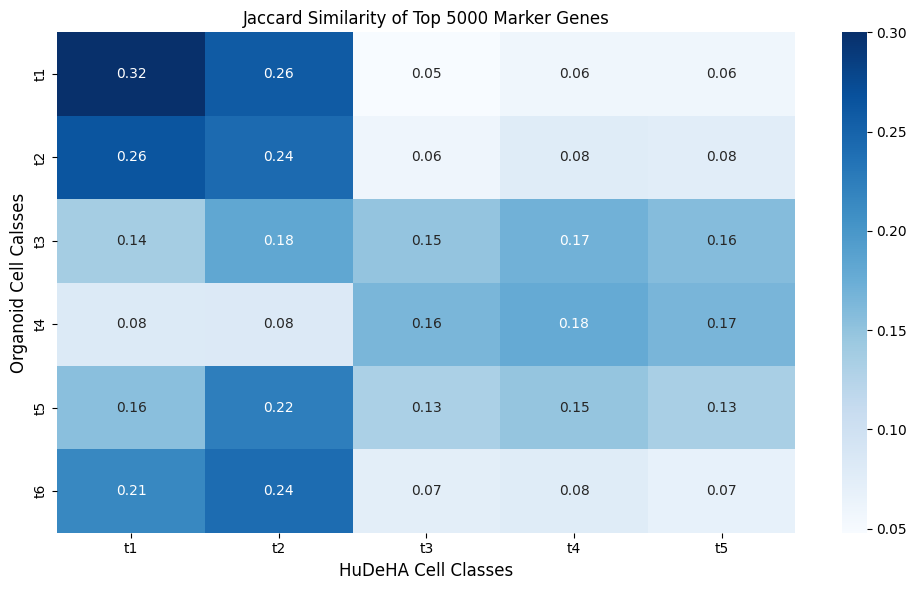

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(jaccard_df, annot=True, cmap='Blues', vmax=0.3, ax=ax,  fmt=".2f")
ax.set_xlabel('HuDeHA Cell Classes', size = 12)
ax.set_ylabel('Organoid Cell Calsses', size = 12)
ax.set_title(f'Jaccard Similarity of Top {top_n} Marker Genes')
fig.tight_layout()

fig.savefig( os.path.join(outdir, f"jaccard_timepoints_{top_n}_on_all.pdf"), bbox_inches="tight")

plt.show()

In [43]:
top_n = 5000

In [44]:
jaccard_df = compute_jaccard_marker_similarity(
    df_reference=df_markers_atlas_common,
    df_query=df_markers_adata_randall_common,
    top_n=top_n
)

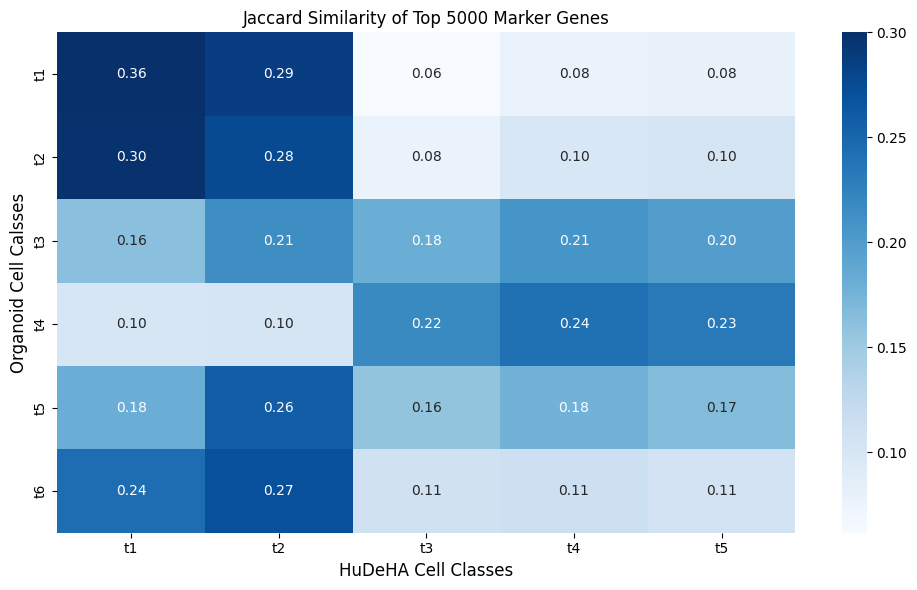

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(jaccard_df, annot=True, cmap='Blues', vmax=0.3, ax=ax,  fmt=".2f")
ax.set_xlabel('HuDeHA Cell Classes', size = 12)
ax.set_ylabel('Organoid Cell Calsses', size = 12)
ax.set_title(f'Jaccard Similarity of Top {top_n} Marker Genes')
fig.tight_layout()

fig.savefig( os.path.join(outdir, f"jaccard_timepoints_{top_n}_on_common.pdf"), bbox_inches="tight")

plt.show()

In [50]:
import gc
gc.collect()

45248

In [52]:
ct_atlas = df_markers_atlas_common['group'].unique()  # <-- already strings
ct_randall = df_markers_adata_randall_common['group'].unique()

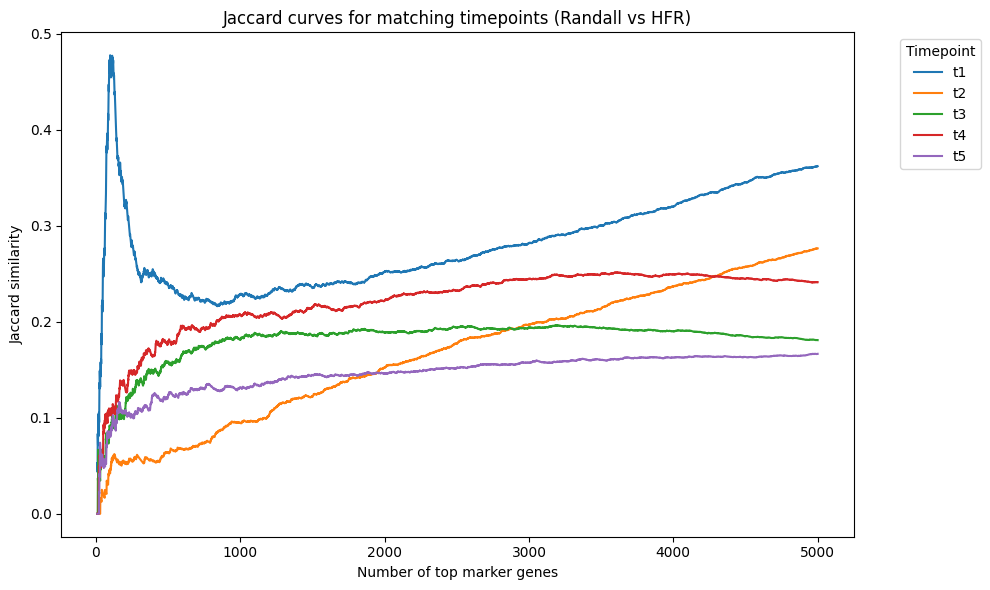

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Dense vector of gene cutoffs
top_ns = np.arange(10, 5001, 1)

results = {}

# Get the intersection of cell types present in both datasets
common_cts = sorted(set(ct_randall) & set(ct_atlas))

for ct in common_cts:
    sims = []
    for n in top_ns:
        set1 = set(df_markers_adata_randall_common[df_markers_adata_randall_common['group'] == ct]['names'].head(n))
        set2 = set(df_markers_atlas_common[df_markers_atlas_common['group'] == ct]['names'].head(n))
        intersection = set1 & set2
        union = set1 | set2
        jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan
        sims.append(jaccard)
    results[ct] = sims

fig, ax = plt.subplots(figsize=(10, 6))

for ct, sims in results.items():
    ax.plot(top_ns, sims, label=ct)

ax.set_xlabel("Number of top marker genes")
ax.set_ylabel("Jaccard similarity")
ax.set_title("Jaccard curves for matching timepoints (Randall vs HFR)")

ax.legend(
    title="Timepoint",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

fig.savefig(
    os.path.join(outdir, "jaccard_curves_Randall_vs_HuDeHA_timepoints.pdf"),
    dpi=300,
    bbox_inches="tight"
)


## Person, spearman, ccc correlations

In [54]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

In [55]:
def mean_by_mask(adata, mask):
    """
    Compute mean expression over cells selected by mask.
    Works with sparse .X; returns 1D np.array (n_genes,).
    """
    X = adata.X[mask]
    m = X.mean(axis=0)
    if hasattr(m, "A1"):  # sparse -> flatten
        m = m.A1
    else:
        m = np.asarray(m).ravel()
    return m


def ccc(x, y):
    """
    Lin's concordance correlation coefficient.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    mx = x.mean()
    my = y.mean()
    vx = x.var()
    vy = y.var()

    if vx == 0 or vy == 0:
        return np.nan

    cov = ((x - mx) * (y - my)).mean()
    rho = cov / np.sqrt(vx * vy)

    ccc_val = (2 * rho * np.sqrt(vx) * np.sqrt(vy)) / (vx + vy + (mx - my) ** 2)
    return ccc_val


def transcriptome_similarity_all_by_all(
    adata_ref,
    adata_qry,
    ct_col_ref="cell_type",
    ct_col_qry="cell_type",
    corr="pearson",     # or "spearman"
    genes=None,
    min_cells=5,        # skip tiny groups
):
    # 1) intersect genes
    if genes is None:
        genes_ref = set(adata_ref.var_names)
        genes_qry = set(adata_qry.var_names)
        genes_use = np.array(sorted(genes_ref & genes_qry))
    else:
        genes_use = np.array([g for g in genes
                              if g in adata_ref.var_names and g in adata_qry.var_names])

    if len(genes_use) == 0:
        raise ValueError("No overlapping genes between reference and query.")

    # 2) subset both to same genes (view)
    ad_ref = adata_ref[:, genes_use]
    ad_qry = adata_qry[:, genes_use]

    # 3) get unique cell types
    cts_ref = sorted(ad_ref.obs[ct_col_ref].unique())
    cts_qry = sorted(ad_qry.obs[ct_col_qry].unique())

    # 4) precompute means per CT for ref
    ref_means = {}
    ref_counts = {}
    for ct in cts_ref:
        mask = (ad_ref.obs[ct_col_ref] == ct).values
        n = int(mask.sum())
        ref_counts[ct] = n
        if n >= min_cells:
            ref_means[ct] = mean_by_mask(ad_ref, mask)
        else:
            ref_means[ct] = None  # mark as too small

    # 5) precompute means per CT for query
    qry_means = {}
    qry_counts = {}
    for ct in cts_qry:
        mask = (ad_qry.obs[ct_col_qry] == ct).values
        n = int(mask.sum())
        qry_counts[ct] = n
        if n >= min_cells:
            qry_means[ct] = mean_by_mask(ad_qry, mask)
        else:
            qry_means[ct] = None

    # 6) pairwise compare
    rows = []
    for ct_r in cts_ref:
        v_ref = ref_means[ct_r]
        for ct_q in cts_qry:
            v_qry = qry_means[ct_q]

            if (v_ref is None) or (v_qry is None):
                rows.append({
                    "ct_ref": ct_r,
                    "ct_qry": ct_q,
                    "n_ref": ref_counts[ct_r],
                    "n_qry": qry_counts[ct_q],
                    "corr": np.nan,
                    "ccc": np.nan,
                })
                continue

            # correlation
            if corr == "pearson":
                c = np.corrcoef(v_ref, v_qry)[0, 1]
            elif corr == "spearman":
                c, _ = spearmanr(v_ref, v_qry)
            else:
                raise ValueError("corr must be 'pearson' or 'spearman'")

            # concordance
            c_conc = ccc(v_ref, v_qry)
            spearm, _ = spearmanr(v_ref, v_qry)
            rows.append({
                "ct_ref": ct_r,
                "ct_qry": ct_q,
                "n_ref": ref_counts[ct_r],
                "n_qry": qry_counts[ct_q],
                "pearson": float(c),
                'spearm' : float(spearm), 
                "ccc": float(c_conc) if c_conc is not None else np.nan,
            })

    df_long = pd.DataFrame(rows)

    # optional: pivot to matrix form
    # corr_matrix = df_long.pivot(index="ct_ref", columns="ct_qry", values="corr")
    # ccc_matrix = df_long.pivot(index="ct_ref", columns="ct_qry", values="ccc")

    return df_long

In [56]:
common_genes = set(adata_atlas.var_names) & set(adata_randall.var_names)
len(common_genes)
atlas_sub = adata_atlas[:, list(common_genes)].copy()
adata_randall_sub = adata_randall[:, list(common_genes)].copy()

In [57]:
del(adata_atlas)
del(adata_randall)
import gc
gc.collect()

9429

In [58]:
sc.pp.highly_variable_genes(
    atlas_sub,
    n_top_genes=3000,
    flavor="seurat_v3"
)

sc.pp.highly_variable_genes(
    adata_randall_sub,
    n_top_genes=3000,
    flavor="seurat_v3"
)

# 2) extract HVG names
hvg_atlas   = set(atlas_sub.var_names[atlas_sub.var["highly_variable"]])
hvg_randall = set(adata_randall_sub.var_names[adata_randall_sub.var["highly_variable"]])

# 3) intersection and union
hvg_intersection = hvg_atlas & hvg_randall
hvg_union        = hvg_atlas | hvg_randall

print("atlas_sub HVGs:", len(hvg_atlas))
print("adata_randall_sub HVGs:", len(hvg_randall))
print("intersection:", len(hvg_intersection))
print("union:", len(hvg_union))


/home/bnvlab2/miniconda3/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


atlas_sub HVGs: 3000

adata_randall_sub HVGs: 3000

intersection: 992

union: 5008

In [59]:
adata_randall_sub.obs['t_bin_custom'].value_counts()

t_bin_custom
t3    5540
t6    3932
t2    3094
t4    2452
t5    1447
t1     831
Name: count, dtype: int64

In [60]:
atlas_sub.obs['t_bin_custom_upd'].value_counts()

t_bin_custom_upd
t2    8450
t1    5679
t3    2205
t4    1270
t5     396
Name: count, dtype: int64

In [75]:
geneset = 'hvg_union'

In [78]:
df_intersect2 = transcriptome_similarity_all_by_all(  atlas_sub,
    adata_randall_sub, 
    genes = hvg_union,
    ct_col_ref="t_bin_custom_upd",    
    ct_col_qry="t_bin_custom")

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
outdir = "/home/bnvlab2/scVI_brain/Supplementary/Jaccard"

In [90]:
genesets = {
    "hvg_atlas": hvg_atlas,
    "hvg_randall": hvg_randall,
    "hvg_intersection": hvg_intersection,
    "hvg_union": hvg_union,
}


In [91]:
os.makedirs(outdir, exist_ok=True)

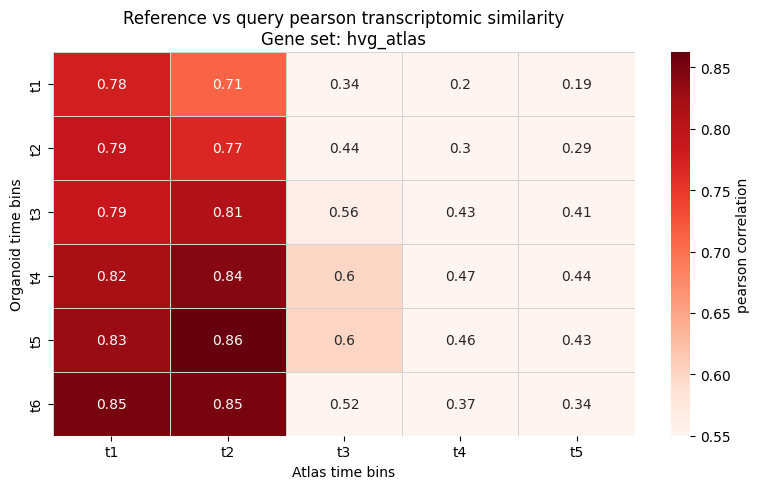

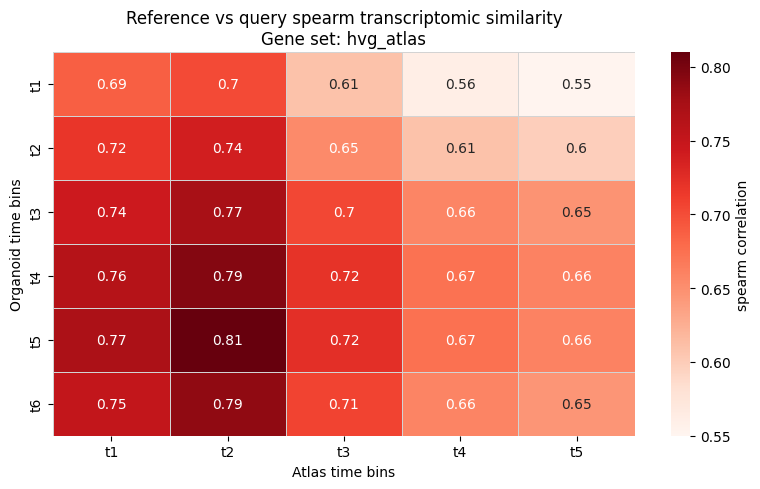

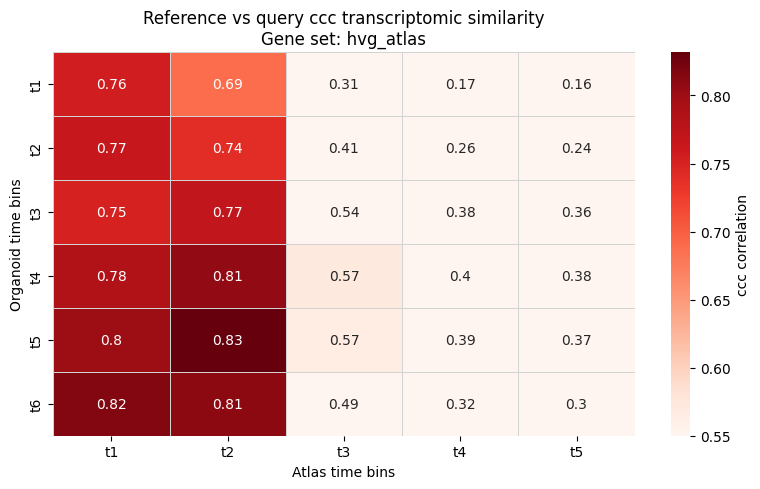

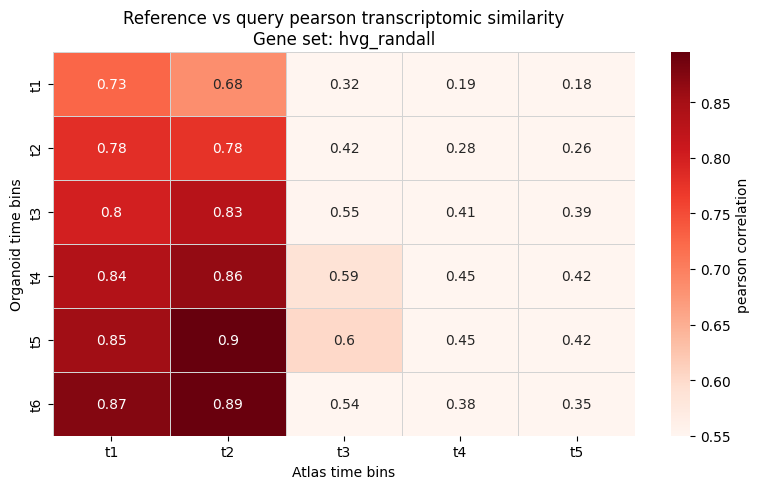

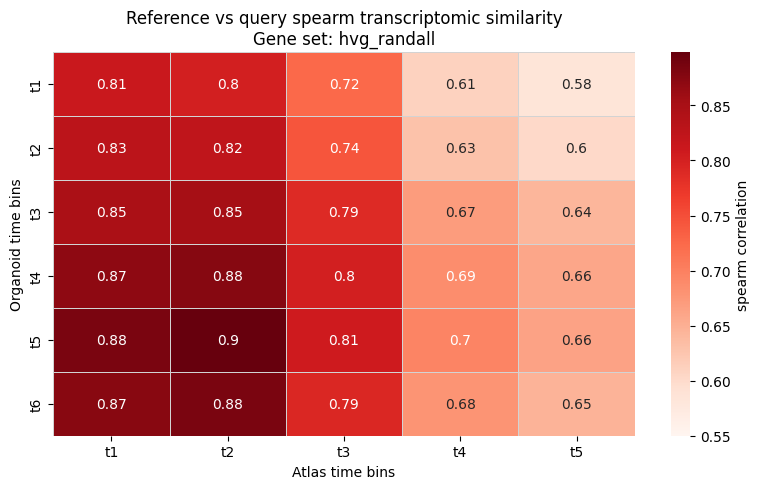

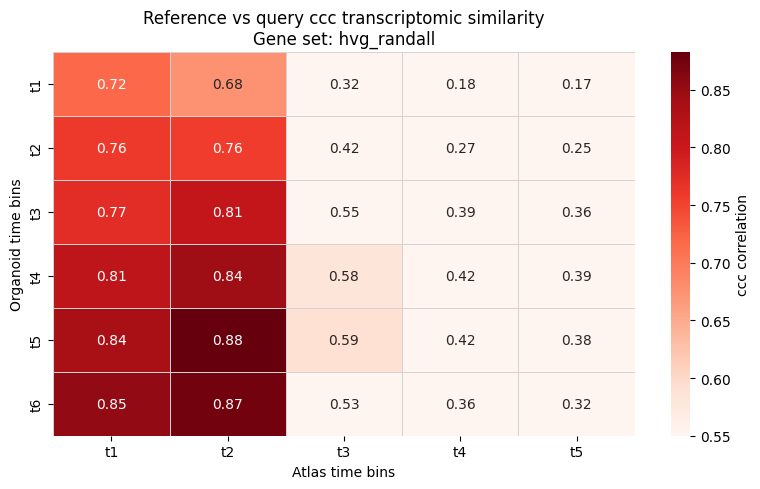

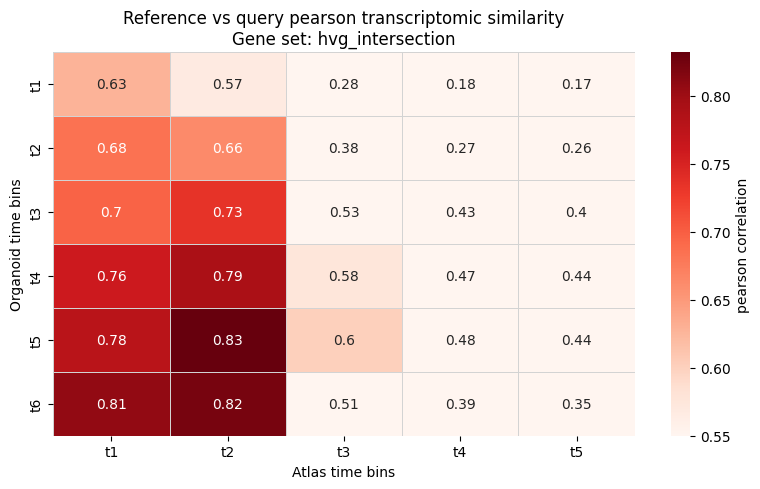

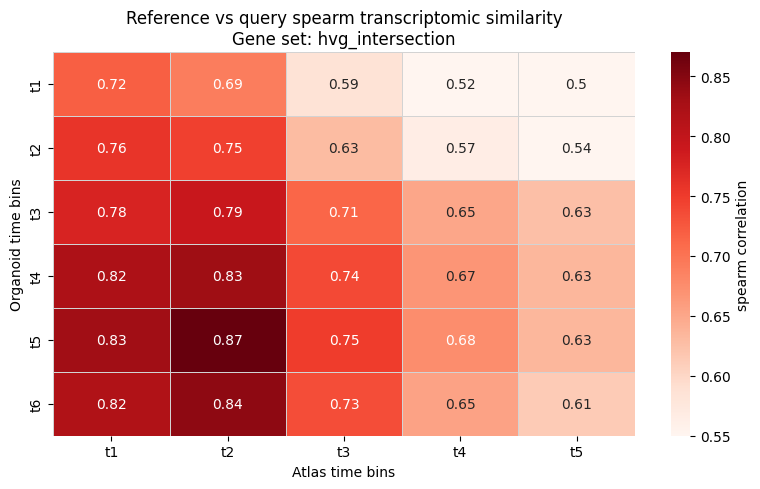

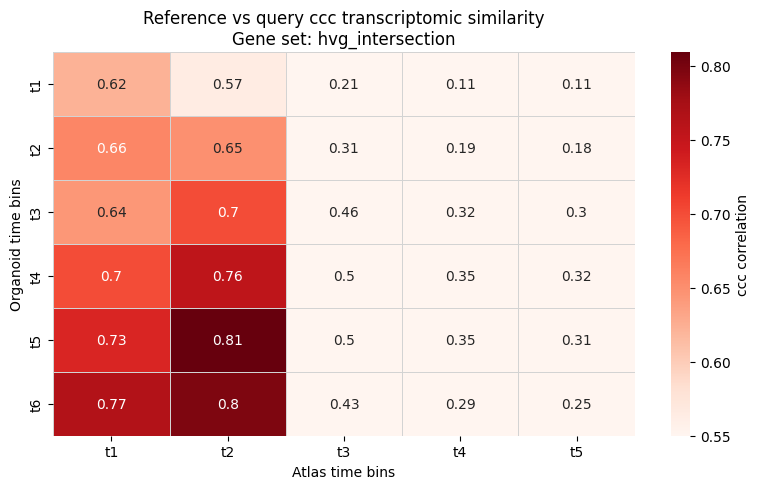

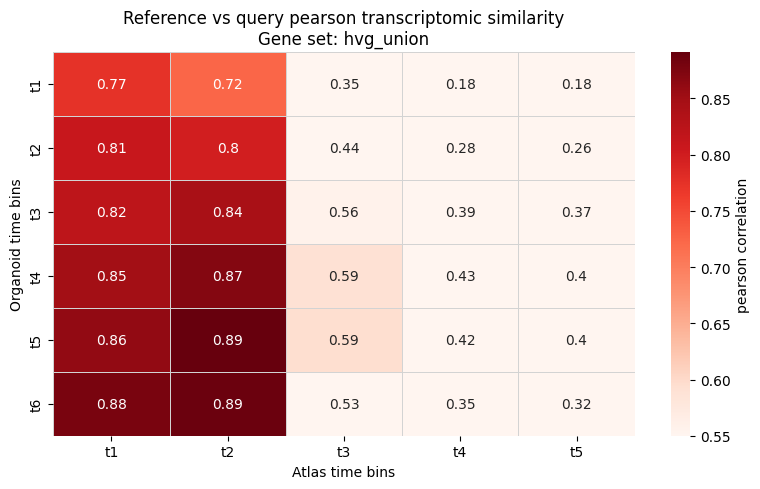

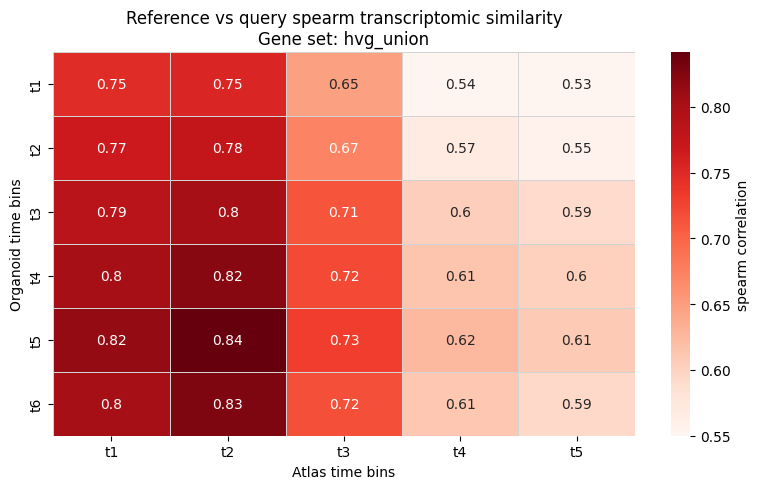

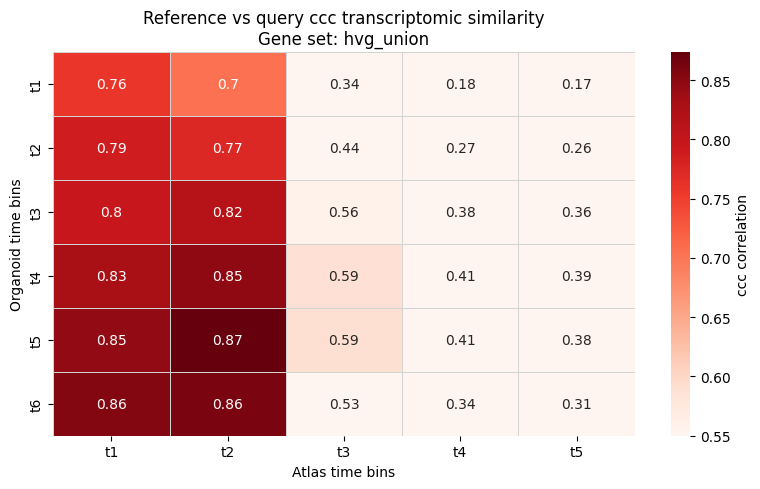

In [92]:
for geneset_name, geneset in genesets.items():
    
    df_intersect2 = transcriptome_similarity_all_by_all(
        atlas_sub,
        adata_randall_sub,
        genes=geneset,
        ct_col_ref="t_bin_custom_upd",
        ct_col_qry="t_bin_custom"
    )

    for corr in ["pearson", "spearm", "ccc"]:
        
        corr_mat_intersect = df_intersect2.pivot(
            index="ct_ref",
            columns="ct_qry",
            values=corr
        )
        
        fig, ax = plt.subplots(figsize=(8, 5))
        
        sns.heatmap(
            corr_mat_intersect.T,
            linewidths=0.5,
            linecolor="lightgray",
            cbar_kws={"label": f"{corr} correlation"},
            annot=True,
            cmap="Reds",
            vmin=0.55,
            ax=ax
        )
        
        ax.set_xlabel("Atlas time bins")
        ax.set_ylabel("Organoid time bins")
        ax.set_title(
            f"Reference vs query {corr} transcriptomic similarity\n"
            f"Gene set: {geneset_name}"
        )
        
        plt.tight_layout()
        
        fig.savefig(
            os.path.join(outdir, f"timepoint_{corr}_on_{geneset_name}.pdf"),
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()
        plt.close(fig)

## WT

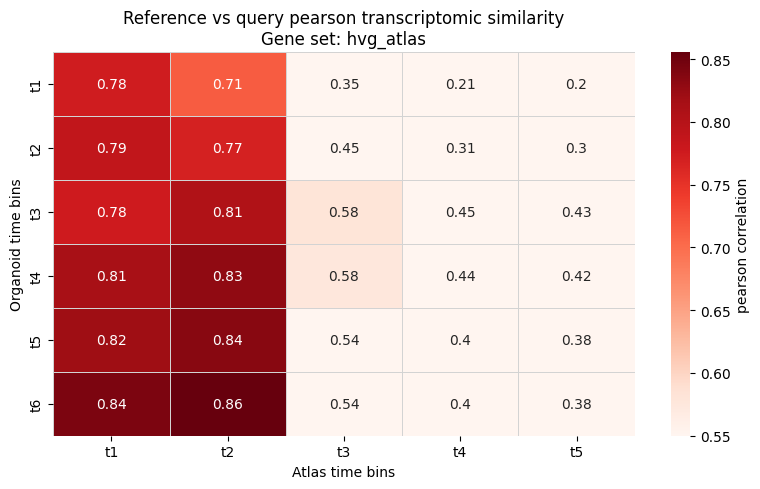

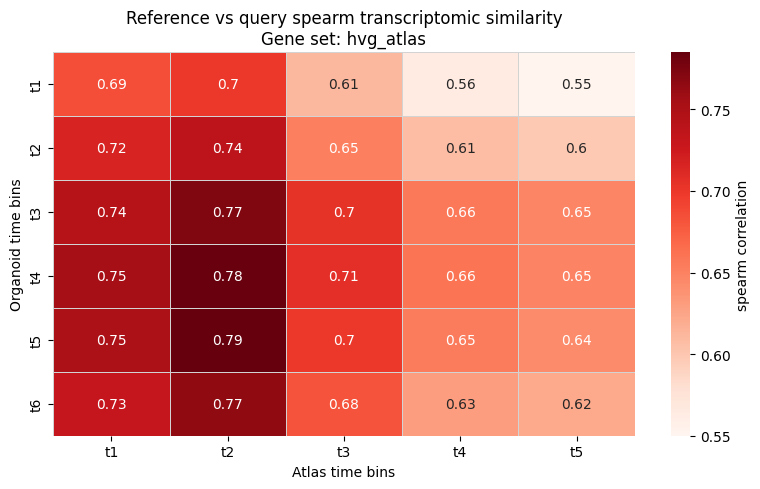

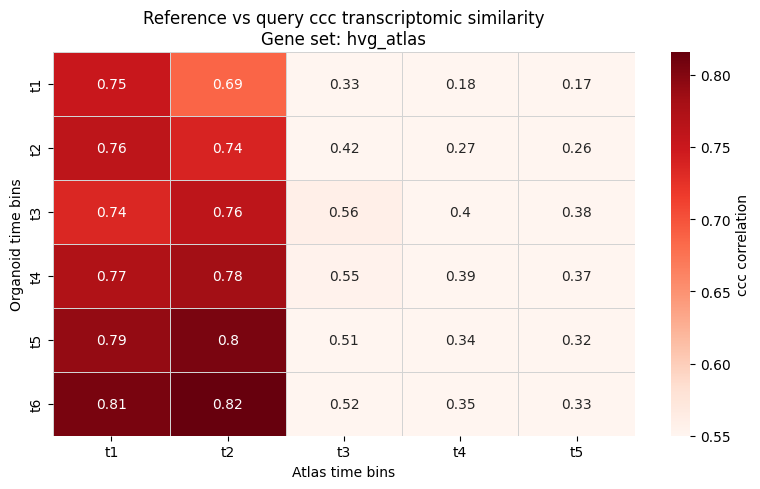

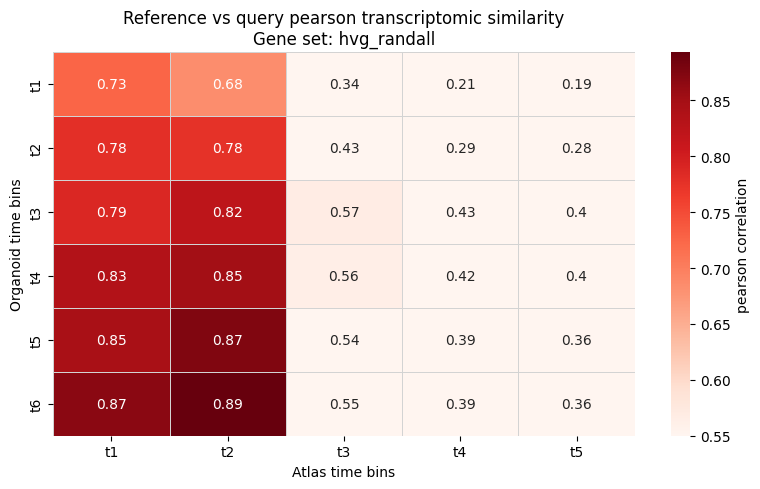

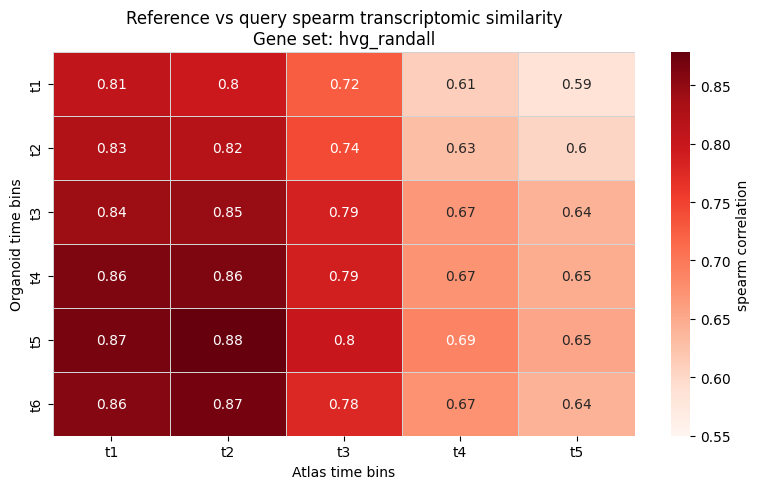

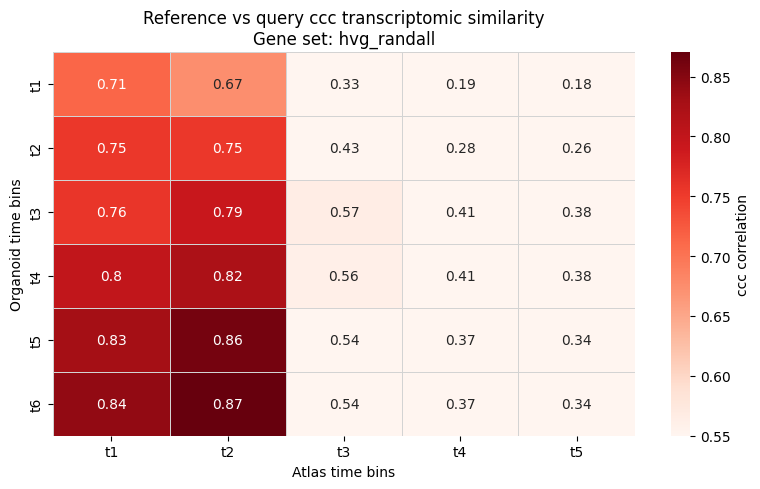

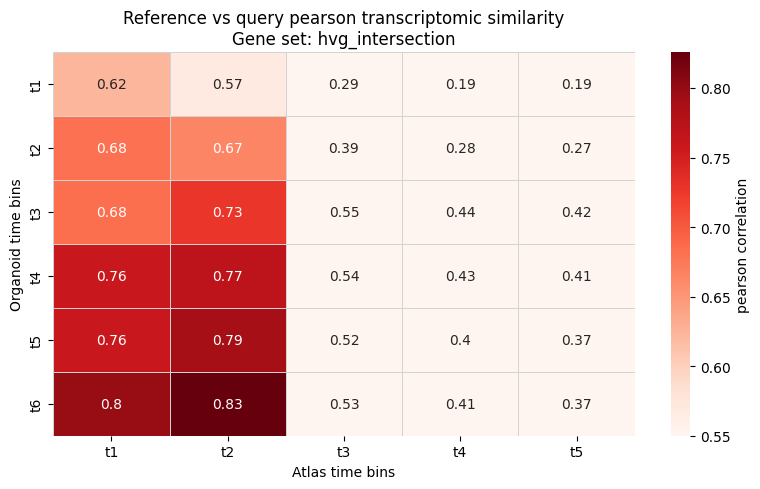

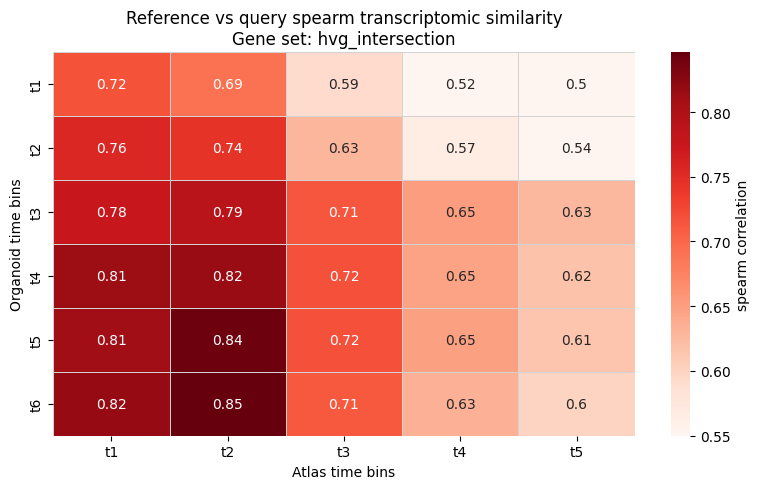

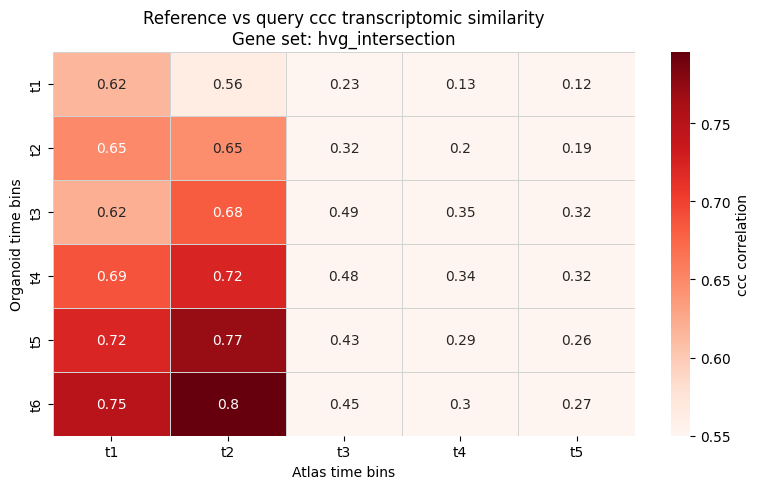

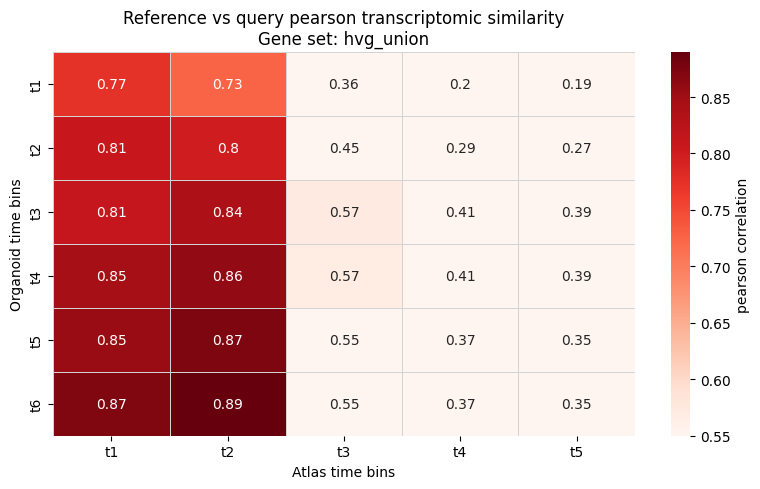

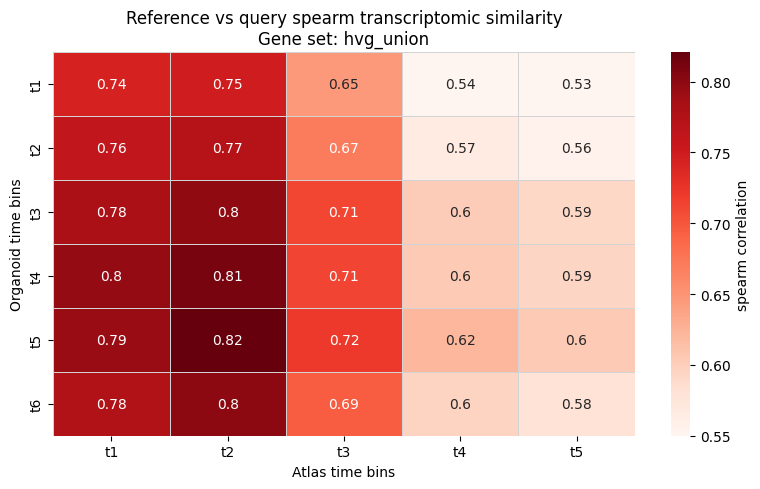

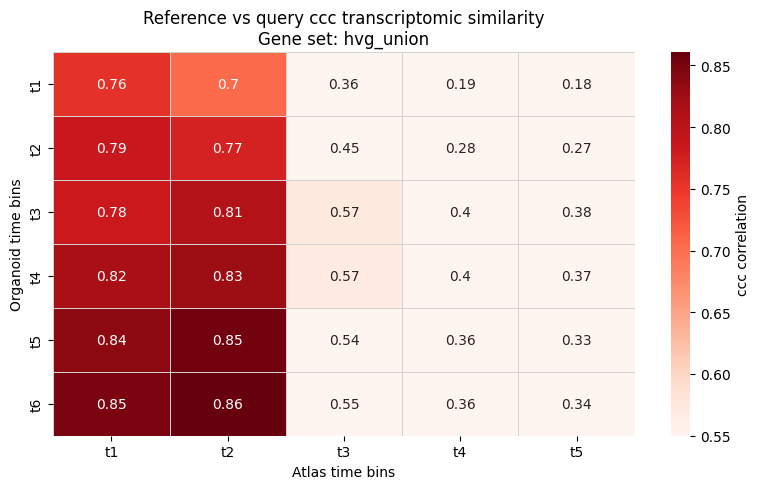

In [93]:
for geneset_name, geneset in genesets.items():
    
    df_intersect2 = transcriptome_similarity_all_by_all(
        atlas_sub,
        adata_full_WT_sub,
        genes=geneset,
        ct_col_ref="t_bin_custom_upd",
        ct_col_qry="t_bin_custom"
    )

    for corr in ["pearson", "spearm", "ccc"]:
        
        corr_mat_intersect = df_intersect2.pivot(
            index="ct_ref",
            columns="ct_qry",
            values=corr
        )
        
        fig, ax = plt.subplots(figsize=(8, 5))
        
        sns.heatmap(
            corr_mat_intersect.T,
            linewidths=0.5,
            linecolor="lightgray",
            cbar_kws={"label": f"{corr} correlation"},
            annot=True,
            cmap="Reds",
            vmin=0.55,
            ax=ax
        )
        
        ax.set_xlabel("Atlas time bins")
        ax.set_ylabel("Organoid time bins")
        ax.set_title(
            f"Reference vs query {corr} transcriptomic similarity\n"
            f"Gene set: {geneset_name}"
        )
        
        plt.tight_layout()
        
        fig.savefig(
            os.path.join(outdir, f"timepoint_{corr}_on_{geneset_name}_WT.pdf"),
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()
        plt.close(fig)

## MUT

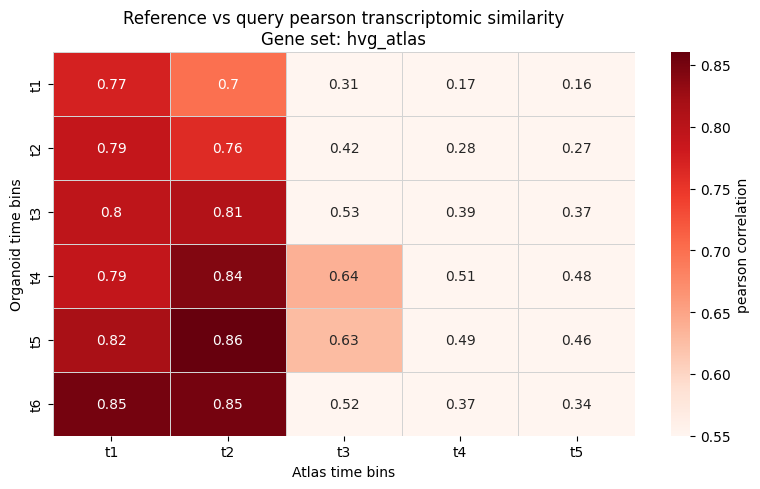

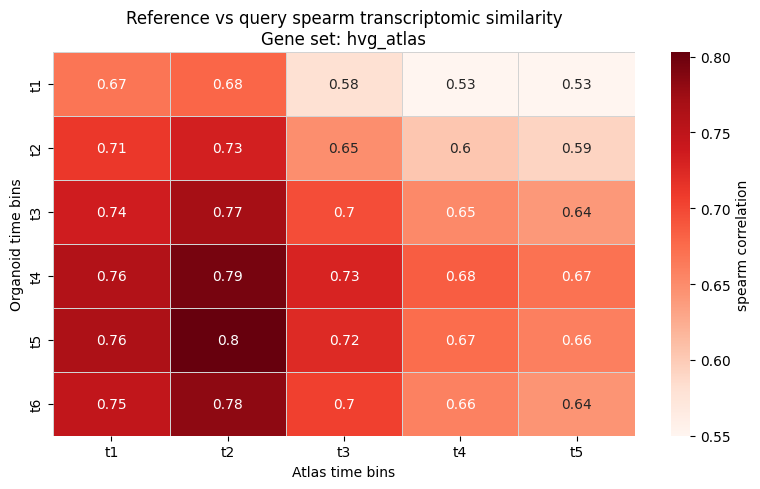

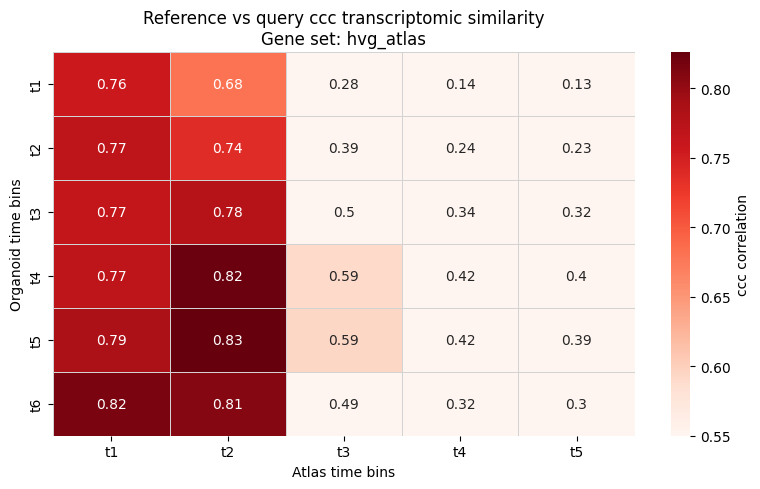

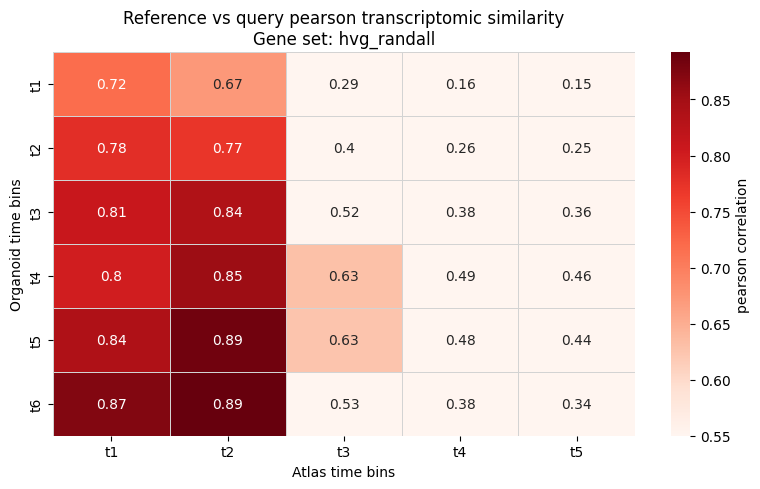

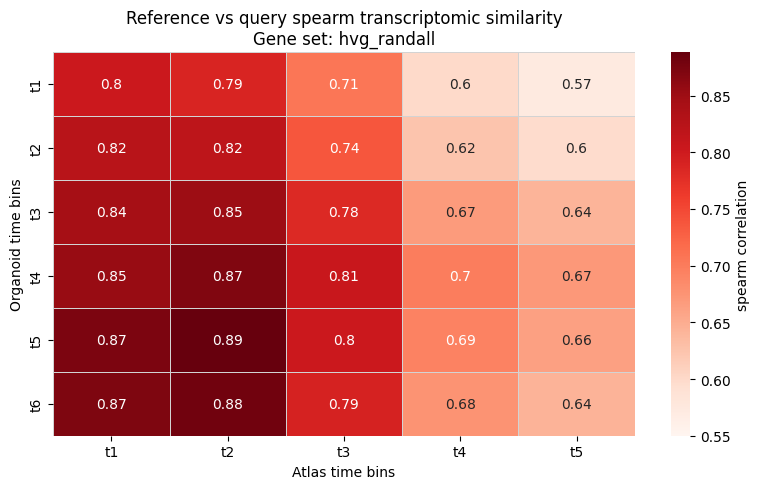

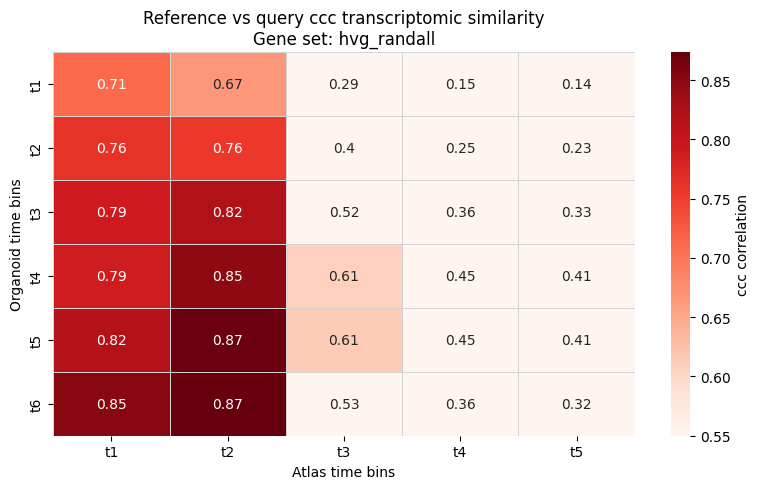

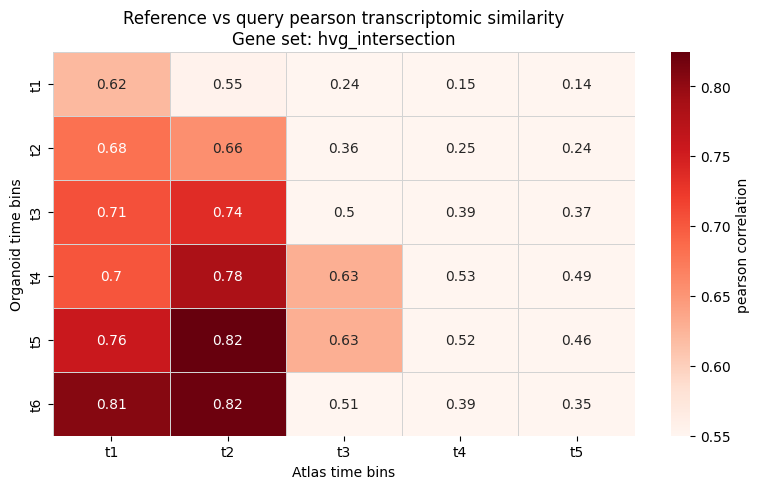

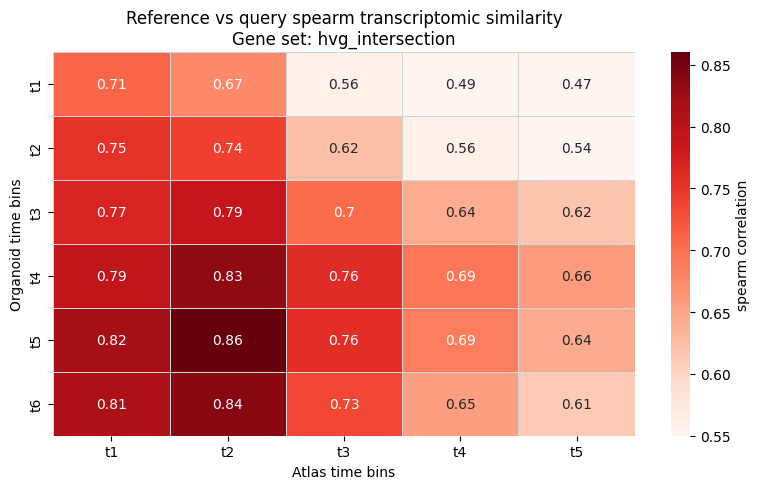

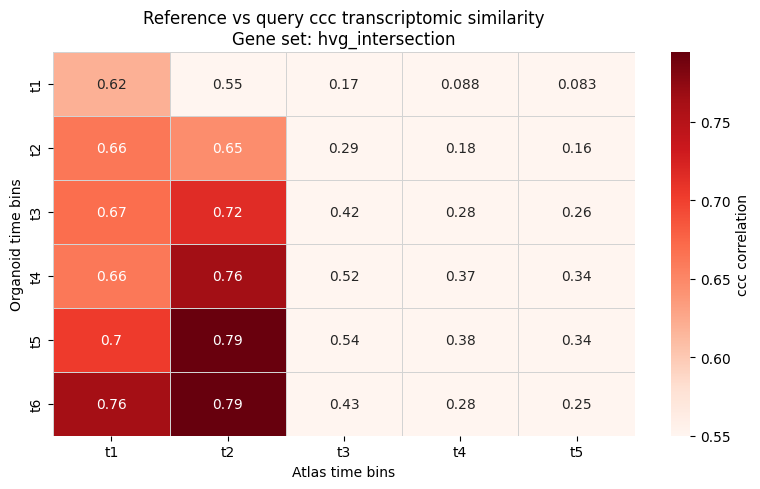

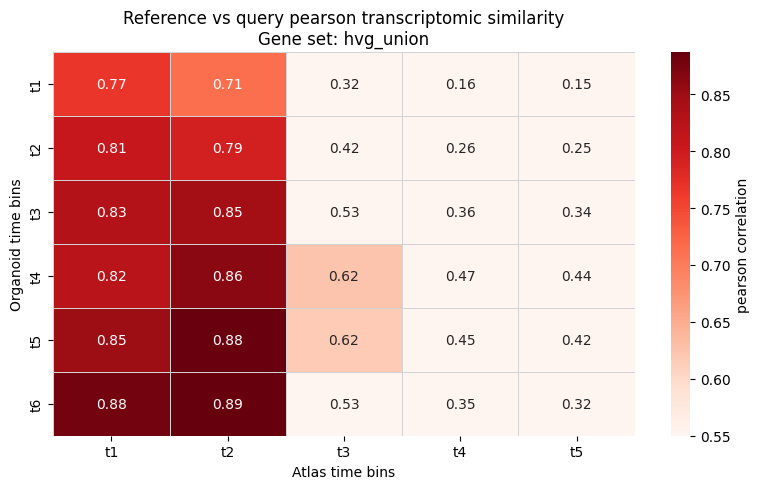

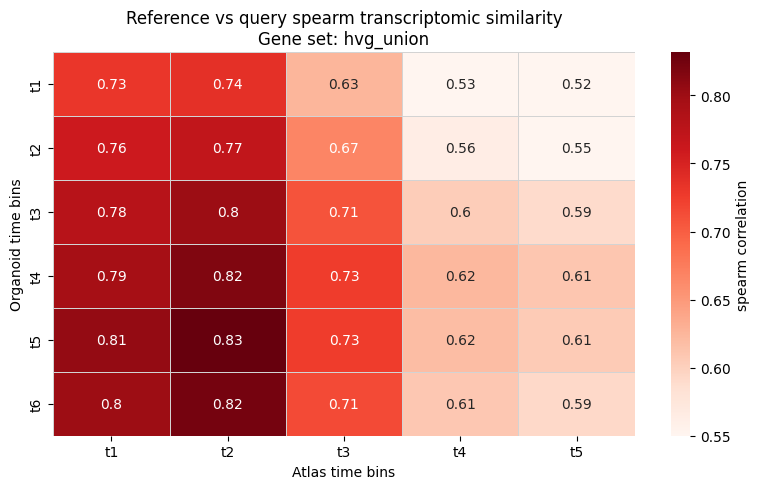

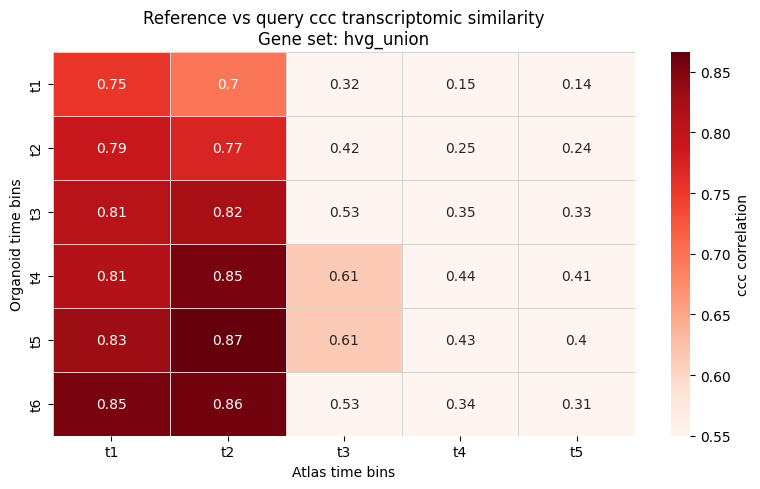

In [94]:
for geneset_name, geneset in genesets.items():
    
    df_intersect2 = transcriptome_similarity_all_by_all(
        atlas_sub,
        adata_full_MUT_sub,
        genes=geneset,
        ct_col_ref="t_bin_custom_upd",
        ct_col_qry="t_bin_custom"
    )

    for corr in ["pearson", "spearm", "ccc"]:
        
        corr_mat_intersect = df_intersect2.pivot(
            index="ct_ref",
            columns="ct_qry",
            values=corr
        )
        
        fig, ax = plt.subplots(figsize=(8, 5))
        
        sns.heatmap(
            corr_mat_intersect.T,
            linewidths=0.5,
            linecolor="lightgray",
            cbar_kws={"label": f"{corr} correlation"},
            annot=True,
            cmap="Reds",
            vmin=0.55,
            ax=ax
        )
        
        ax.set_xlabel("Atlas time bins")
        ax.set_ylabel("Organoid time bins")
        ax.set_title(
            f"Reference vs query {corr} transcriptomic similarity\n"
            f"Gene set: {geneset_name}"
        )
        
        plt.tight_layout()
        
        fig.savefig(
            os.path.join(outdir, f"timepoint_{corr}_on_{geneset_name}_MUT.pdf"),
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()
        plt.close(fig)